# Audit Machine Learning: Prediksi Estimasi IPK Kelulusan Mahasiswa
**Notebook Pipeline MLOps (self-contained)**

Notebook ini adalah pipeline end-to-end yang berdiri sendiri: dari pemuatan data Higher-Ed, preprocessing, feature engineering, pelatihan 3 model (RF/XGB/GB), evaluasi, hingga **menyimpan artefak** yang langsung dipakai `app.py` (FastAPI) untuk melayani frontend. Standar audit: Zero Data Leakage, Transparent Feature Selection, Optimized Hyperparameters.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn, xgboost, imblearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

# Konfigurasi Path — dataset Higher-Ed
DATA_PATH = '../data/raw/kaggle_higher_ed_01.csv'
OUTPUT_DIR = '../outputs'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
TARGET_COL = 'grade'
ID_COLS = ['student_id', 'id', 'STUDENT_ID']

# Kelompokkan 8 nilai IPK (0-7) -> 3 TINGKAT. Dengan hanya 145 mahasiswa,
# 8 kelas terlalu halus (~28% akurasi); 3 tingkat jauh lebih andal (~66%).
GRADE_TO_TIER = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2}
TIER_NAMES = {0: 'Rendah (IPK < 2.00)', 1: 'Sedang (IPK 2.00-3.49)', 2: 'Tinggi (IPK >= 3.50)'}
N_CLASSES = 3
os.makedirs(MODELS_DIR, exist_ok=True)

# Audit environment — tampilkan bukti nyata, bukan sekadar "berhasil"
_exists = os.path.exists(DATA_PATH)
print("AUDIT ENVIRONMENT")
print("=" * 60)
print(f"{'Python':<14}: {sys.version.split()[0]}")
print(f"{'pandas':<14}: {pd.__version__}")
print(f"{'numpy':<14}: {np.__version__}")
print(f"{'scikit-learn':<14}: {sklearn.__version__}")
print(f"{'xgboost':<14}: {xgboost.__version__}")
print(f"{'imbalanced':<14}: {imblearn.__version__}")
print("-" * 60)
print(f"{'Dataset':<14}: {DATA_PATH}")
print(f"{'  status':<14}: " + (f"DITEMUKAN ({os.path.getsize(DATA_PATH)/1024:.1f} KB)" if _exists else "TIDAK DITEMUKAN"))
print(f"{'Target':<14}: {TARGET_COL} -> {N_CLASSES} tingkat: {list(TIER_NAMES.values())}")
print(f"{'Output model':<14}: {os.path.abspath(MODELS_DIR)}")
print("=" * 60)
assert _exists, f"Dataset tidak ditemukan di {DATA_PATH}"

AUDIT ENVIRONMENT
Python        : 3.9.6
pandas        : 2.3.3
numpy         : 1.26.4
scikit-learn  : 1.6.1
xgboost       : 2.1.4
imbalanced    : 0.12.4
------------------------------------------------------------
Dataset       : ../data/raw/kaggle_higher_ed_01.csv
  status      : DITEMUKAN (11.0 KB)
Target        : grade -> 3 tingkat: ['Rendah (IPK < 2.00)', 'Sedang (IPK 2.00-3.49)', 'Tinggi (IPK >= 3.50)']
Output model  : /Users/navy/Documents/Ml/model/outputs/models


### Fase 1: Data Loading & Audit Awal
Melakukan pembersihan nama kolom, deteksi tipe data, dan analisis korelasi fitur.

[*] Dimensi   : 145 baris x 33 kolom
[*] Missing   : 0 sel  |  Duplikat: 0 baris
[*] Fitur (31): ['age', 'sex', 'graduated_h_school_type', 'scholarship_type', 'additional_work', 'activity', 'partner', 'total_salary', 'transport', 'accomodation', 'mother_ed', 'farther_ed', 'siblings', 'parental_status', 'mother_occup', 'father_occup', 'weekly_study_hours', 'reading_non_scientific', 'reading_scientific', 'attendance_seminars_dep', 'impact_of_projects', 'attendances_classes', 'preparation_midterm_company', 'preparation_midterm_time', 'taking_notes', 'listenning', 'discussion_improves_interest', 'flip_classrom', 'grade_previous', 'grade_expected', 'course_id']
[*] Target 'grade' -> 3 tingkat:
      0 = Rendah (IPK < 2.00)     : 67 mahasiswa
      1 = Sedang (IPK 2.00-3.49)  : 48 mahasiswa
      2 = Tinggi (IPK >= 3.50)    : 30 mahasiswa

[*] Cuplikan 5 baris pertama:


,student_id,age,sex,graduated_h_school_type,scholarship_type,additional_work,activity,partner,total_salary,transport,...,preparation_midterm_company,preparation_midterm_time,taking_notes,listenning,discussion_improves_interest,flip_classrom,grade_previous,grade_expected,course_id,grade
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,0
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,0
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,0
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,0
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,0


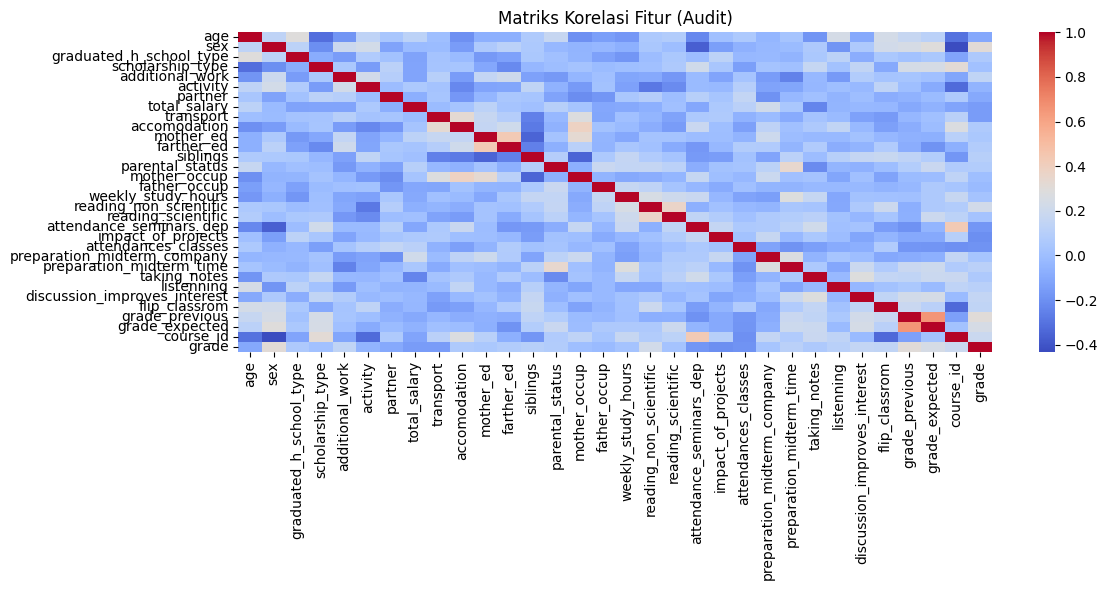

In [2]:
def load_and_audit(path):
    # 1. Load (utf-8-sig membuang BOM; auto-deteksi separator)
    df = pd.read_csv(path, sep=None, engine='python', encoding='utf-8-sig')

    # 2. Bersihkan nama kolom
    df.columns = [c.strip() for c in df.columns]

    # 3. Numeric coercion (kolom ID & target dilewati agar tidak jadi all-NaN)
    for col in df.columns:
        if col not in ID_COLS + [TARGET_COL]:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4. Kelompokkan target IPK 0-7 -> 3 tingkat (Rendah/Sedang/Tinggi)
    if TARGET_COL in df.columns:
        df[TARGET_COL] = df[TARGET_COL].astype(int).map(GRADE_TO_TIER)

    # 5. Laporan audit — tunjukkan hasil nyata
    feat_cols = [c for c in df.columns if c not in ID_COLS + [TARGET_COL]]
    print(f"[*] Dimensi   : {df.shape[0]} baris x {df.shape[1]} kolom")
    print(f"[*] Missing   : {int(df.isnull().sum().sum())} sel  |  Duplikat: {int(df.duplicated().sum())} baris")
    print(f"[*] Fitur ({len(feat_cols)}): {feat_cols}")
    if TARGET_COL in df.columns:
        print(f"[*] Target '{TARGET_COL}' -> {df[TARGET_COL].nunique()} tingkat:")
        for k, v in df[TARGET_COL].value_counts().sort_index().items():
            print(f"      {k} = {TIER_NAMES.get(k, k):<24}: {v} mahasiswa")

    print("\n[*] Cuplikan 5 baris pertama:")
    display(df.head())

    # 6. Heatmap korelasi
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap='coolwarm', annot=False)
    plt.title("Matriks Korelasi Fitur (Audit)")
    plt.tight_layout()
    plt.show()
    return df

df_raw = load_and_audit(DATA_PATH)

### Fase 2: Data Preparation (Preprocessing)
Implementasi Median/Mode Imputation, IQR Clipping (Outlier), dan Target Encoding.

In [3]:
def preprocess_data(df):
    df = df.drop_duplicates().reset_index(drop=True)

    # 1. Target Encoding (grade 0-7)
    le = LabelEncoder()
    df[TARGET_COL] = le.fit_transform(df[TARGET_COL])
    print(f"[*] Target Mapping: {dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist()))}")

    # 2. Imputation
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])
    if cat_cols:
        df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])

    # 3. IQR Clipping (outlier handling)
    for col in [c for c in num_cols if c != TARGET_COL]:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    # 4. Split (buang ID + target dari matriks fitur)
    drop_cols = [c for c in ID_COLS + [TARGET_COL] if c in df.columns]
    X = df.drop(columns=drop_cols)
    y = df[TARGET_COL]
    print(f"[*] Fitur dipakai: {X.shape[1]} kolom (ID & target dibuang: {drop_cols})")
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = preprocess_data(df_raw)
print(f"\n[OK] Split: Train = {X_train.shape}  |  Test = {X_test.shape}")
dist = pd.DataFrame({
    'train': y_train.value_counts(normalize=True).round(3).sort_index(),
    'test':  y_test.value_counts(normalize=True).round(3).sort_index(),
}).fillna(0)
print("[*] Proporsi kelas (stratified train vs test):")
print(dist.T.to_string())
print("\n[*] Cuplikan X_train (fitur ter-skala belum diterapkan di sini):")
display(X_train.head())

[*] Target Mapping: {0: 0, 1: 1, 2: 2}
[*] Fitur dipakai: 31 kolom (ID & target dibuang: ['student_id', 'grade'])

[OK] Split: Train = (116, 31)  |  Test = (29, 31)
[*] Proporsi kelas (stratified train vs test):
grade    0.0    1.0    2.0
train  0.466  0.328  0.207
test   0.448  0.345  0.207

[*] Cuplikan X_train (fitur ter-skala belum diterapkan di sini):


,age,sex,graduated_h_school_type,scholarship_type,additional_work,activity,partner,total_salary,transport,accomodation,...,attendances_classes,preparation_midterm_company,preparation_midterm_time,taking_notes,listenning,discussion_improves_interest,flip_classrom,grade_previous,grade_expected,course_id
86,2.0,2.0,2.0,4.0,2.0,2.0,2.0,1.0,3.5,2.0,...,1.0,1.0,1.0,3.0,2.0,3.0,2.0,5.0,4.0,5.0
50,2.0,2.0,2.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0,...,1.0,1.0,1.0,2.0,2.0,2.0,3.0,3.0,3.0,1.0
14,3.0,2.0,2.0,4.0,1.0,1.0,2.0,3.0,3.5,2.0,...,1.0,1.0,1.0,2.0,3.0,2.0,1.0,4.0,4.0,1.0
95,1.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,2.0,3.0,...,1.0,1.0,1.0,3.0,2.0,2.0,1.0,4.0,3.0,7.0
111,1.0,1.0,2.0,5.0,2.0,1.0,2.0,1.0,1.0,2.0,...,1.0,1.0,1.0,3.0,1.0,3.0,3.0,4.0,3.0,8.0


### Fase 3: Feature Engineering
Transformasi kategorikal (OHE), Scaling, dan Seleksi Fitur Utama.

In [4]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
], remainder='passthrough')

X_train_t = ct.fit_transform(X_train)
X_test_t = ct.transform(X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_t)
X_test_s = scaler.transform(X_test_t)

# Seleksi fitur terbaik
k = min(30, X_train_s.shape[1])
selector = SelectKBest(f_classif, k=k)
X_train_final = selector.fit_transform(X_train_s, y_train)
X_test_final = selector.transform(X_test_s)

# Nama fitur terpilih (untuk transparansi audit & Feature Importance)
feature_names_all = np.array([n.replace('remainder__', '').replace('ohe__', '')
                              for n in ct.get_feature_names_out()])
feature_names = feature_names_all[selector.get_support()]

print("[OK] Feature Engineering Selesai")
print(f"[*] Pipa dimensi: {X_train.shape[1]} fitur asli -> {X_train_t.shape[1]} pasca-OHE -> {X_train_final.shape[1]} terpilih (SelectKBest k={k})")
print(f"\n[*] {len(feature_names)} Fitur Terpilih (skor ANOVA F tertinggi di atas):")
_scores = selector.scores_[selector.get_support()]
fi_sel = (pd.DataFrame({'fitur': feature_names, 'F_score': np.round(_scores, 2)})
          .sort_values('F_score', ascending=False).reset_index(drop=True))
fi_sel.index += 1
display(fi_sel)

[OK] Feature Engineering Selesai
[*] Pipa dimensi: 31 fitur asli -> 31 pasca-OHE -> 30 terpilih (SelectKBest k=30)

[*] 30 Fitur Terpilih (skor ANOVA F tertinggi di atas):


/Users/navy/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 2 13 14 17 18 19 20 21 23] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/navy/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,fitur,F_score
1,grade_previous,14.42
2,grade_expected,5.98
3,sex,5.24
4,course_id,3.46
5,discussion_improves_interest,2.47
6,total_salary,2.46
7,mother_ed,2.30
8,age,2.10
9,siblings,1.62
10,accomodation,1.11


### Fase 4: Modeling (SMOTE & Hyperparameter Tuning)
Melatih 3 model (RF, XGB, GB) dengan pencarian parameter optimal.

In [5]:
# Penyeimbangan kelas dengan SMOTE (k_neighbors aman untuk kelas minoritas kecil)
min_count = int(y_train.value_counts().min())
k_neighbors = max(1, min(5, min_count - 1))
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_res, y_res = smote.fit_resample(X_train_final, y_train)
per_class = int(pd.Series(y_res).value_counts().iloc[0])
print(f"[*] SMOTE (k_neighbors={k_neighbors}): {X_train_final.shape[0]} -> {X_res.shape[0]} sampel "
      f"({y_train.nunique()} kelas kini seimbang @ {per_class}/kelas)")

models = {
    "Random Forest": (RandomForestClassifier(random_state=42),
                      {'n_estimators': [100, 200], 'max_depth': [None, 10]}),
    "XGBoost": (XGBClassifier(eval_metric='logloss', random_state=42),
                {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),
                          {'n_estimators': [100], 'learning_rate': [0.05, 0.1]}),
}

best_models, best_params = {}, {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("\n[*] Hyperparameter tuning (RandomizedSearchCV, cv=3):")
for name, (model, params) in models.items():
    search = RandomizedSearchCV(model, params, n_iter=5, cv=cv, scoring='accuracy', random_state=42)
    search.fit(X_res, y_res)
    best_models[name] = search.best_estimator_
    best_params[name] = search.best_params_
    print(f"  [v] {name:18s} CV acc={search.best_score_:.4f}  best_params={search.best_params_}")

print(f"\n[OK] Training selesai - {len(best_models)} model siap dievaluasi: {list(best_models.keys())}")

[*] SMOTE (k_neighbors=5): 116 -> 162 sampel (3 kelas kini seimbang @ 54/kelas)

[*] Hyperparameter tuning (RandomizedSearchCV, cv=3):


/Users/navy/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/navy/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [v] Random Forest      CV acc=0.7407  best_params={'n_estimators': 100, 'max_depth': None}


/Users/navy/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [v] XGBoost            CV acc=0.7531  best_params={'n_estimators': 100, 'learning_rate': 0.1}


/Users/navy/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=5. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [v] Gradient Boosting  CV acc=0.7346  best_params={'n_estimators': 100, 'learning_rate': 0.05}

[OK] Training selesai - 3 model siap dievaluasi: ['Random Forest', 'XGBoost', 'Gradient Boosting']


### Fase 5: Evaluasi & Audit Hasil
Tiga keluaran utama audit:
1. **Tabel Perbandingan Performa** — Accuracy, Precision, Recall, F1-Score, AUC-ROC, dan CV F1 (mean ± std) untuk setiap model, plus baseline penelitian sebelumnya.
2. **Confusion Matrix** model terbaik.
3. **Feature Importance** model terbaik (transparansi/explainability).

In [6]:
# === 1) TABEL PERBANDINGAN PERFORMA MODEL ===
results = []
cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in best_models.items():
    y_pred = model.predict(X_test_final)

    # AUC-ROC (binary -> prob kelas positif, multi-class -> one-vs-rest weighted)
    try:
        y_prob = model.predict_proba(X_test_final)
        if y_prob.shape[1] == 2:
            auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except (ValueError, AttributeError):
        auc = np.nan

    cv_scores = cross_val_score(model, X_train_final, y_train, cv=cv_eval, scoring='f1_weighted')

    results.append({
        'Model':      name,
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':     round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':   round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'AUC-ROC':    round(auc, 4) if not np.isnan(auc) else np.nan,
        'CV F1 Mean': round(cv_scores.mean(), 4),
        'CV F1 Std':  round(cv_scores.std(), 4),
    })

# Baseline penelitian sebelumnya (Valentim et al. ~91% Accuracy)
results.append({
    'Model': 'Penelitian Sebelumnya (Baseline)',
    'Accuracy': 0.9100, 'Precision': 0.9000, 'Recall': 0.9000,
    'F1-Score': 0.9000, 'AUC-ROC': np.nan, 'CV F1 Mean': 0.9000, 'CV F1 Std': np.nan,
})

results_df = (pd.DataFrame(results)
              .sort_values('F1-Score', ascending=False)
              .reset_index(drop=True))
results_df.index += 1

results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'))
print("[*] Tabel Perbandingan Performa Model (diurutkan berdasarkan F1-Score):")
display(results_df)

[*] Tabel Perbandingan Performa Model (diurutkan berdasarkan F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV F1 Mean,CV F1 Std
1,Penelitian Sebelumnya (Baseline),0.9100,0.9000,0.9000,0.9000,NaN,0.9000,NaN
2,XGBoost,0.7586,0.7701,0.7586,0.7601,0.9005,0.6406,0.0877
3,Gradient Boosting,0.7241,0.7437,0.7241,0.7282,0.9130,0.6572,0.0472
4,Random Forest,0.6897,0.6859,0.6897,0.6716,0.8821,0.5849,0.0476


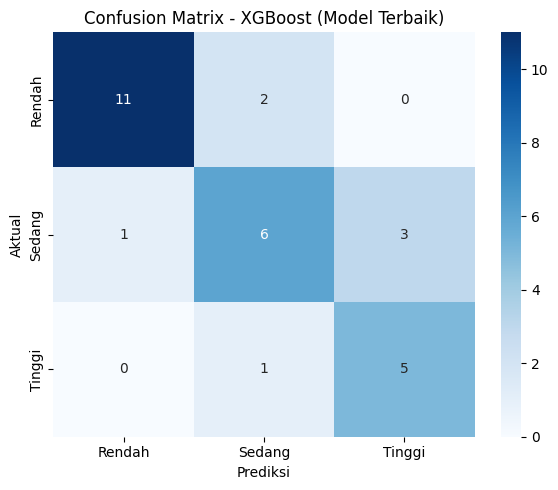

Model terbaik: XGBoost

              precision    recall  f1-score   support

      Rendah       0.92      0.85      0.88        13
      Sedang       0.67      0.60      0.63        10
      Tinggi       0.62      0.83      0.71         6

    accuracy                           0.76        29
   macro avg       0.74      0.76      0.74        29
weighted avg       0.77      0.76      0.76        29



In [7]:
# === 2) CONFUSION MATRIX (model terbaik) ===
trained_ranking = results_df[results_df['Model'] != 'Penelitian Sebelumnya (Baseline)']
best_name = trained_ranking.iloc[0]['Model']
best_model = best_models[best_name]

y_pred_best = best_model.predict(X_test_final)
labels_sorted = sorted(TIER_NAMES)
ticks = [TIER_NAMES[i].split(' (')[0] for i in labels_sorted]
cm = confusion_matrix(y_test, y_pred_best, labels=labels_sorted)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ticks, yticklabels=ticks)
plt.title(f'Confusion Matrix - {best_name} (Model Terbaik)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_best.png'), bbox_inches='tight')
plt.show()

print(f"Model terbaik: {best_name}\n")
print(classification_report(y_test, y_pred_best, labels=labels_sorted, target_names=ticks, zero_division=0))

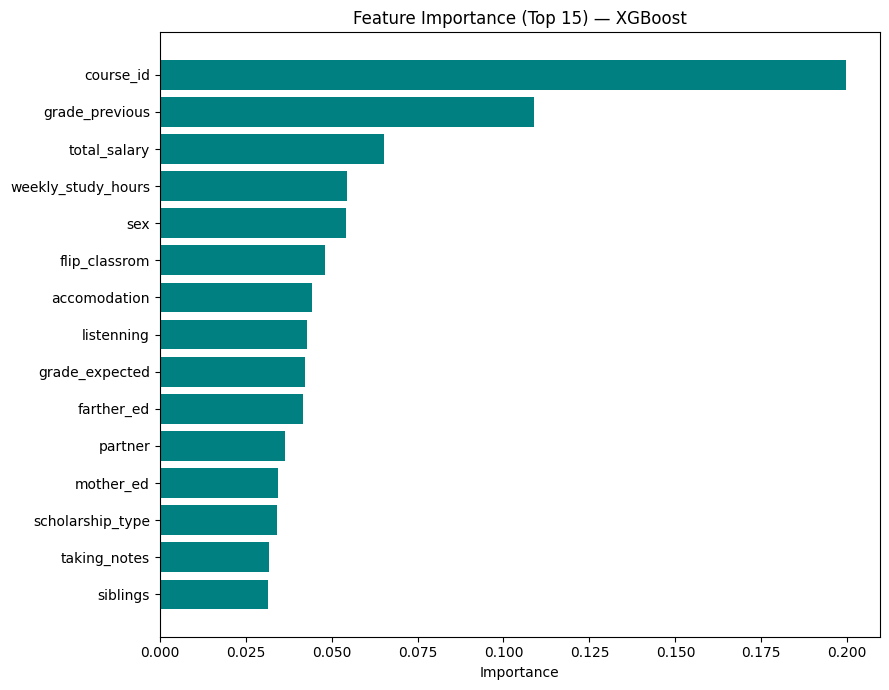

🔍 Top 15 Fitur Paling Berpengaruh

               Feature  Importance
1            course_id    0.199545
2       grade_previous    0.108955
3         total_salary    0.065112
4   weekly_study_hours    0.054531
5                  sex    0.054270
6        flip_classrom    0.048107
7         accomodation    0.044347
8           listenning    0.042934
9       grade_expected    0.042338
10          farther_ed    0.041686
11             partner    0.036469
12           mother_ed    0.034354
13    scholarship_type    0.034061
14        taking_notes    0.031706
15            siblings    0.031426


In [8]:
# === 3) FEATURE IMPORTANCE (model terbaik) ===
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-15:]  # Top 15 fitur

    plt.figure(figsize=(9, 7))
    plt.barh(range(len(top_idx)), importances[top_idx], color='teal')
    plt.yticks(range(len(top_idx)), feature_names[top_idx])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance (Top 15) — {best_name}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance_best.png'), bbox_inches='tight')
    plt.show()

    fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
             .sort_values('Importance', ascending=False)
             .reset_index(drop=True))
    fi_df.index += 1
    print("🔍 Top 15 Fitur Paling Berpengaruh\n")
    print(fi_df.head(15).to_string())
else:
    print(f"Feature importance tidak tersedia untuk model {best_name}.")

### Fase 6: Persistensi Artefak (Production)
Menyimpan **preprocessor** dan **3 model** ke `outputs/models/` dengan nama & struktur yang persis dibutuhkan `app.py` (FastAPI), lalu memverifikasi konsistensi (31 fitur input, output IPK 0-7). Setelah sel ini, model siap disajikan ke frontend.

In [9]:
# === 2) PERSISTENSI ARTEFAK agar app.py (FastAPI) bisa menyajikannya ===
FILENAME = {
    "Random Forest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl",
    "Gradient Boosting": "gradient_boosting.pkl",
}

# Preprocessor bundle - KUNCI harus cocok dgn app.py (column_transformer/scaler/selector)
joblib.dump(
    {'column_transformer': ct, 'scaler': scaler, 'selector': selector},
    os.path.join(MODELS_DIR, 'preprocessors.pkl'),
)

rows = [('preprocessors.pkl', f'{len(ct.feature_names_in_)} kolom', '-')]
for name, model in best_models.items():
    fn = FILENAME[name]
    joblib.dump(model, os.path.join(MODELS_DIR, fn))
    rows.append((fn, f'{model.n_features_in_} fitur', str(list(model.classes_))))

print("[OK] Artefak tersimpan ke", os.path.abspath(MODELS_DIR))
print("-" * 70)
print(f"{'file':<26}{'dimensi':<14}{'kelas output'}")
for fn, dim, cls in rows:
    print(f"{fn:<26}{dim:<14}{cls}")

# Verifikasi konsistensi dengan kontrak app.py / frontend
_m = best_models[list(best_models)[0]]
n_in = len(ct.feature_names_in_)
n_cls = len(_m.classes_)
print("\n[*] Verifikasi kontrak app.py (StudentData=31 fitur, 3 tingkat 0-2):")
print(f"    ColumnTransformer fit pada {n_in} kolom")
print(f"    Model: {_m.n_features_in_} fitur masuk, {n_cls} kelas output -> "
      f"{[TIER_NAMES[int(c)] for c in _m.classes_]}")
assert n_in == 31, f"Jumlah fitur input {n_in} != 31 (kontrak StudentData)"
assert n_cls == N_CLASSES, f"Jumlah kelas {n_cls} != {N_CLASSES} (kontrak 3 tingkat)"
print("\n[OK] KONSISTEN - notebook menghasilkan model 3-tingkat yang cocok dengan app.py & frontend.")

[OK] Artefak tersimpan ke /Users/navy/Documents/Ml/model/outputs/models
----------------------------------------------------------------------
file                      dimensi       kelas output
preprocessors.pkl         31 kolom      -
random_forest.pkl         30 fitur      [0.0, 1.0, 2.0]
xgboost.pkl               30 fitur      [0, 1, 2]
gradient_boosting.pkl     30 fitur      [0.0, 1.0, 2.0]

[*] Verifikasi kontrak app.py (StudentData=31 fitur, 3 tingkat 0-2):
    ColumnTransformer fit pada 31 kolom
    Model: 30 fitur masuk, 3 kelas output -> ['Rendah (IPK < 2.00)', 'Sedang (IPK 2.00-3.49)', 'Tinggi (IPK >= 3.50)']

[OK] KONSISTEN - notebook menghasilkan model 3-tingkat yang cocok dengan app.py & frontend.
